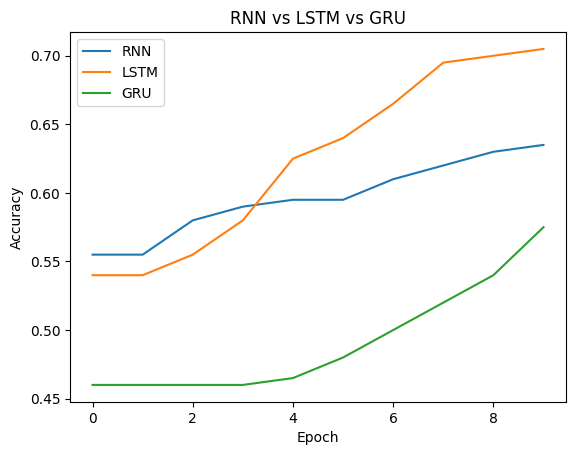

RNN: Final Acc = 0.6350
LSTM: Final Acc = 0.7050
GRU: Final Acc = 0.5750


In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Synthetic data
def make_data(n=1000, seq_len=20):
    X = torch.randn(n, seq_len, 1)
    y = (X.sum(dim=1).squeeze() > 0).long()
    return X, y

X, y = make_data()
X_train, y_train = X[:800], y[:800]
X_test, y_test   = X[800:], y[800:]

# Models
class RNNModel(nn.Module):
    def __init__(self, cell='RNN'):
        super().__init__()
        rnn = {'RNN': nn.RNN, 'LSTM': nn.LSTM, 'GRU': nn.GRU}[cell]
        self.rnn = rnn(1, 32, batch_first=True)
        self.fc  = nn.Linear(32, 2)
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1])

def train(model, epochs=10):
    opt  = torch.optim.Adam(model.parameters())
    loss_fn = nn.CrossEntropyLoss()
    accs = []
    for _ in range(epochs):
        model.train()
        opt.zero_grad()
        loss_fn(model(X_train), y_train).backward()
        opt.step()
        model.eval()
        with torch.no_grad():
            pred = model(X_test).argmax(1)
            accs.append((pred == y_test).float().mean().item())
    return accs

results = {}
for cell in ['RNN', 'LSTM', 'GRU']:
    results[cell] = train(RNNModel(cell))

# Plot
for name, acc in results.items():
    plt.plot(acc, label=name)
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.title('RNN vs LSTM vs GRU'); plt.legend(); plt.show()

for name, acc in results.items():
    print(f"{name}: Final Acc = {acc[-1]:.4f}")